In [16]:
""" Problem 6.2.2 """

import matplotlib.pyplot as plt
import numpy as np
from math import exp, cos, sin, log
from math import pi, sqrt, exp, cos, sin
from cmath import exp
from scipy import linalg
from scipy.linalg import expm

C:\Users\gjsta\AppData\Local\Temp\ipykernel_43424\337303703.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time1[i] = x[0]
C:\Users\gjsta\AppData\Local\Temp\ipykernel_43424\337303703.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time2[i] = x[1]
C:\Users\gjsta\AppData\Local\Temp\ipykernel_43424\337303703.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time3[i] = x[2]


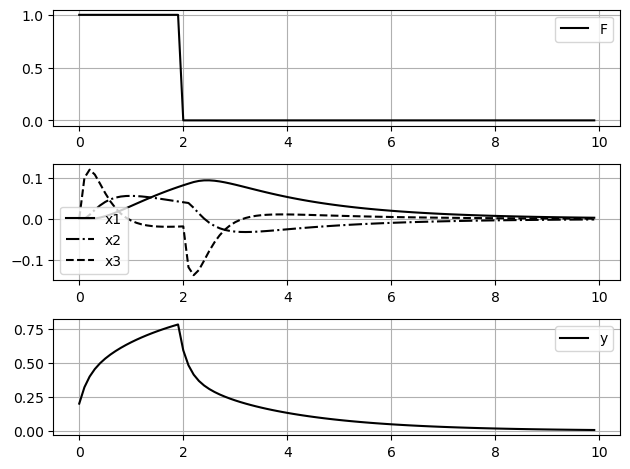

In [26]:
dt = 0.1
NN = int(10/dt)
TT = np.arange(0, dt*NN, dt)
time1 = np.zeros(NN)
time2 = np.zeros(NN)
time3 = np.zeros(NN)

A = np.matrix('0 1 0; 0 0 1; -6 -16 -8')
B = np.matrix('0; 0; 1')
C = np.matrix('6 8 2')
x = np.matrix('0; 0; 0')
u = np.heaviside

x[0] = 0
x[1] = 0
x[2] = 0

f = np.zeros(NN)
f = (u(TT, 1) - u(TT-2, 1))

y = np.zeros(NN)

nsteps = NN

for i in range(nsteps):
    time1[i] = x[0]
    time2[i] = x[1]
    time3[i] = x[2]

    x = x + dt*A*x + dt*B*f[i]

    y[i] = (C*x)[0,0]

plt.figure()
plt.subplot(311)
plt.plot(TT, f, 'k', label = 'F')
plt.legend()
plt.grid()

plt.subplot(312)
plt.plot(TT, time1, 'k', label = 'x1')
plt.plot(TT, time2, 'k-.', label = 'x2')
plt.plot(TT, time3, 'k--', label = 'x3')
plt.legend()
plt.grid()

plt.subplot(313)
plt.plot(TT, y, 'k', label = 'y')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

C:\Users\gjsta\AppData\Local\Temp\ipykernel_49356\4047878705.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wtime1[i] = w[0]
C:\Users\gjsta\AppData\Local\Temp\ipykernel_49356\4047878705.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wtime2[i] = w[1]
C:\Users\gjsta\AppData\Local\Temp\ipykernel_49356\4047878705.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wtime3[i] = w[2]


Text(5, 0.06, 'dt = 0.1')

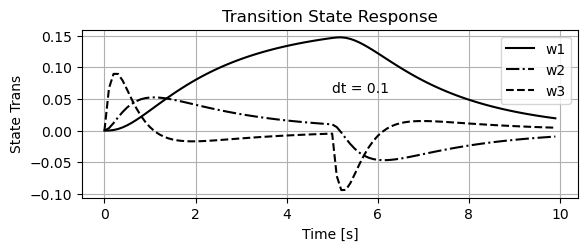

In [35]:
""" OPTIONAL """
""" State Transition Response """

F = expm(A*dt)

Ainv = np.linalg.inv(A)
I2 = np.eye(3)
G1 = (F-I2)*Ainv*B
wtime1 = np.zeros(NN)
wtime2 = np.zeros(NN)
wtime3 = np.zeros(NN)

w = np.matrix('0;0;0')
w[0] = 0
w[1] = 0
w[2] = 0

for i in range(nsteps):
    wtime1[i] = w[0]
    wtime2[i] = w[1]
    wtime3[i] = w[2]

    w = F*w + G1*f[i]

plt.subplot(211)
plt.plot(TT, wtime1, 'k', label = 'w1')
plt.plot(TT, wtime2, 'k-.', label = 'w2')
plt.plot(TT, wtime3, 'k--', label = 'w3')
plt.legend()
plt.grid()
plt.title("Transition State Response")
plt.xlabel("Time [s]")
plt.ylabel("State Trans")
plt.text(5, 0.06, f"dt = {dt}")